# PPG-to-Motion Dataset Validation
Plots one processed segment from each data source to confirm IO and preprocessing are correct.

In [1]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from ppg_to_motion.io.ieee import ieee_generator
from ppg_to_motion.io.ppg_dalia import ppg_dalia_generator

IEEE_ROOT  = r'C:\datasets\IEEE_DSP_CUP'
DALIA_ROOT = r'C:\datasets\ppg+dalia'

## 1  IEEE DSP Cup — first sample

In [2]:
ieee_sample = next(ieee_generator(IEEE_ROOT))

print('=== IEEE DSP Cup ===')
print(f"ID            : {ieee_sample['ID']}")
print(f"source        : {ieee_sample['source']}")
print(f"source_file   : {ieee_sample['source_file']}")
print(f"sampling_rate : {ieee_sample['sampling_rate']} Hz")
print(f"signal shape  : {ieee_sample['signal'].shape}  "
      f"({len(ieee_sample['signal'])/ieee_sample['sampling_rate']:.1f} s)")
print(f"signal dtype  : {ieee_sample['signal'].dtype}")
print(f"acc shape     : {ieee_sample['acc'].shape}")
print(f"label (HR BPM): {ieee_sample['label']:.2f}")

=== IEEE DSP Cup ===
ID            : IEEE_TEST_000000
source        : ieee
source_file   : C:\datasets\IEEE_DSP_CUP\IEEEPPG_TEST.ts
sampling_rate : 125.0 Hz
signal shape  : (1000,)  (8.0 s)
signal dtype  : float32
acc shape     : (3, 1000)
label (HR BPM): 62.70


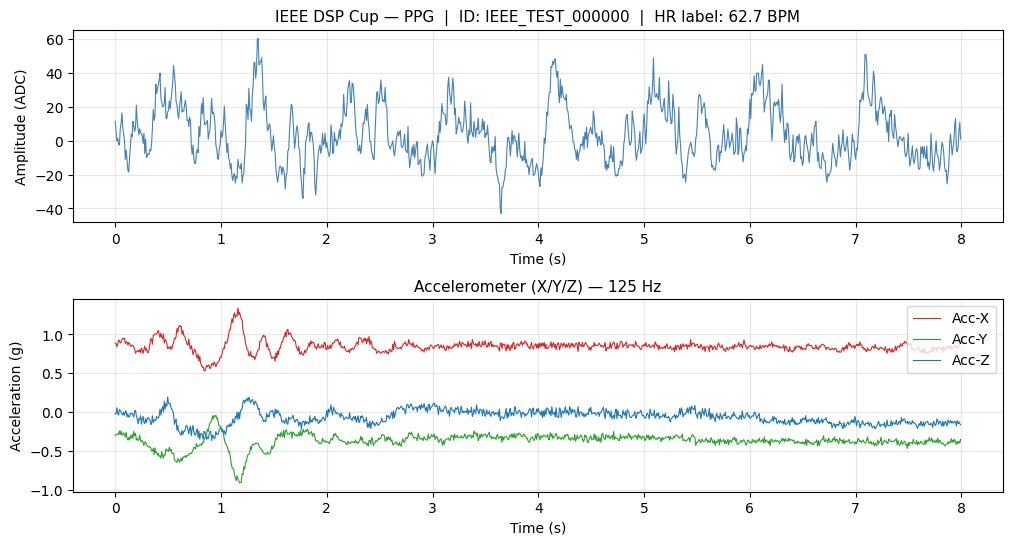

Saved validate_ieee.png


In [3]:
sig  = ieee_sample['signal']
acc  = ieee_sample['acc']
fs   = ieee_sample['sampling_rate']
t    = np.arange(len(sig)) / fs
t_a  = np.arange(acc.shape[1]) / fs

fig = plt.figure(figsize=(12, 6))
gs  = gridspec.GridSpec(2, 1, hspace=0.4)

ax0 = fig.add_subplot(gs[0])
ax0.plot(t, sig, color='steelblue', linewidth=0.8)
ax0.set_title(f"IEEE DSP Cup — PPG  |  ID: {ieee_sample['ID']}  |  "
              f"HR label: {ieee_sample['label']:.1f} BPM", fontsize=11)
ax0.set_xlabel('Time (s)')
ax0.set_ylabel('Amplitude (ADC)')
ax0.grid(True, alpha=0.3)

ax1 = fig.add_subplot(gs[1])
for i, (ch, col) in enumerate(zip(acc, ['tab:red', 'tab:green', 'tab:blue'])):
    ax1.plot(t_a, ch, color=col, linewidth=0.8, label=f'Acc-{"XYZ"[i]}')
ax1.set_title('Accelerometer (X/Y/Z) — 125 Hz', fontsize=11)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Acceleration (g)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

plt.savefig('validate_ieee.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved validate_ieee.png')

## 2  PPG-DaLiA — first 30-second segment

In [4]:
dalia_sample = next(ppg_dalia_generator(DALIA_ROOT))

print('=== PPG-DaLiA ===')
print(f"ID            : {dalia_sample['ID']}")
print(f"source        : {dalia_sample['source']}")
print(f"source_file   : {dalia_sample['source_file']}")
print(f"sampling_rate : {dalia_sample['sampling_rate']} Hz")
print(f"signal shape  : {dalia_sample['signal'].shape}  "
      f"({len(dalia_sample['signal'])/dalia_sample['sampling_rate']:.1f} s)")
print(f"signal dtype  : {dalia_sample['signal'].dtype}")
print(f"acc shape     : {dalia_sample['acc'].shape}")
print(f"label (HR BPM): {dalia_sample.get('label', 'N/A')}")

=== PPG-DaLiA ===
ID            : S1
source        : ppg-dalia
source_file   : C:\datasets\ppg+dalia\data\PPG_FieldStudy\S1
sampling_rate : 64.0 Hz
signal shape  : (1920,)  (30.0 s)
signal dtype  : float32
acc shape     : (3, 1920)
label (HR BPM): 61.28248596191406


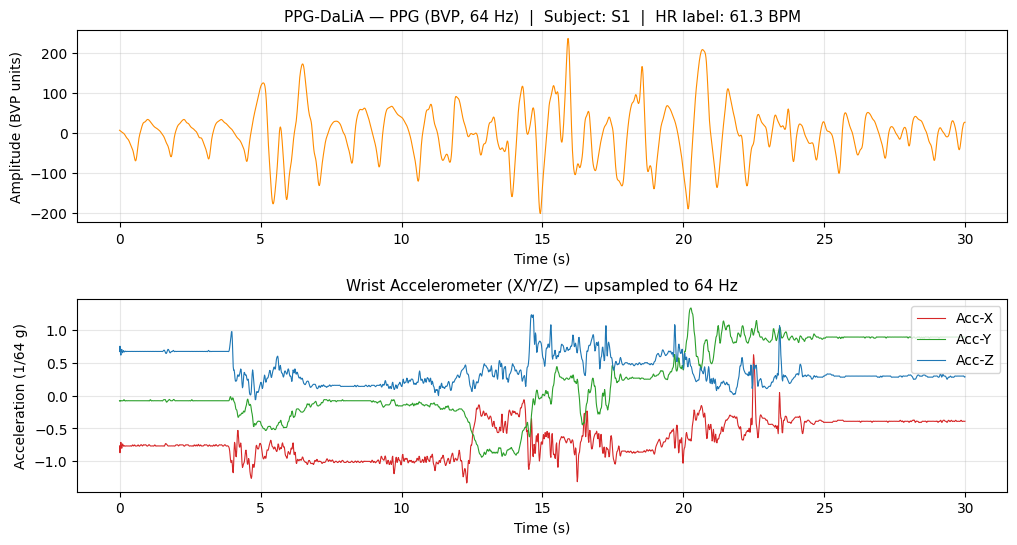

Saved validate_dalia.png


In [5]:
sig  = dalia_sample['signal']
acc  = dalia_sample['acc']
fs   = dalia_sample['sampling_rate']
t    = np.arange(len(sig)) / fs
t_a  = np.arange(acc.shape[1]) / fs

fig = plt.figure(figsize=(12, 6))
gs  = gridspec.GridSpec(2, 1, hspace=0.4)

ax0 = fig.add_subplot(gs[0])
ax0.plot(t, sig, color='darkorange', linewidth=0.8)
label_str = f"{dalia_sample['label']:.1f} BPM" if 'label' in dalia_sample else 'N/A'
ax0.set_title(f"PPG-DaLiA — PPG (BVP, 64 Hz)  |  Subject: {dalia_sample['ID']}  |  "
              f"HR label: {label_str}", fontsize=11)
ax0.set_xlabel('Time (s)')
ax0.set_ylabel('Amplitude (BVP units)')
ax0.grid(True, alpha=0.3)

ax1 = fig.add_subplot(gs[1])
for i, (ch, col) in enumerate(zip(acc, ['tab:red', 'tab:green', 'tab:blue'])):
    ax1.plot(t_a, ch, color=col, linewidth=0.8, label=f'Acc-{"XYZ"[i]}')
ax1.set_title('Wrist Accelerometer (X/Y/Z) — upsampled to 64 Hz', fontsize=11)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Acceleration (1/64 g)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

plt.savefig('validate_dalia.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved validate_dalia.png')

## 3  Segment statistics check

In [6]:
import itertools

print('Counting segments per source (first 200 each) ...')

ieee_gen   = ieee_generator(IEEE_ROOT)
dalia_gen  = ppg_dalia_generator(DALIA_ROOT)

ieee_samples  = list(itertools.islice(ieee_gen, 200))
dalia_samples = list(itertools.islice(dalia_gen, 200))

for name, samples in [('IEEE DSP Cup', ieee_samples), ('PPG-DaLiA', dalia_samples)]:
    fs_vals   = set(s['sampling_rate'] for s in samples)
    sig_lens  = set(len(s['signal']) for s in samples)
    acc_shapes = set(s['acc'].shape for s in samples)
    has_label = sum(1 for s in samples if 'label' in s)
    subjects  = set(s['ID'] for s in samples)
    print(f'\n{name} (first 200 segments):')
    print(f'  sampling rates  : {fs_vals}')
    print(f'  signal lengths  : {sig_lens}')
    print(f'  acc shapes      : {acc_shapes}')
    print(f'  segments w/label: {has_label} / {len(samples)}')
    print(f'  unique IDs seen : {len(subjects)} → {sorted(subjects)[:5]} ...')

Counting segments per source (first 200 each) ...



IEEE DSP Cup (first 200 segments):
  sampling rates  : {125.0}
  signal lengths  : {1000}
  acc shapes      : {(3, 1000)}
  segments w/label: 200 / 200
  unique IDs seen : 200 → ['IEEE_TEST_000000', 'IEEE_TEST_000001', 'IEEE_TEST_000002', 'IEEE_TEST_000003', 'IEEE_TEST_000004'] ...

PPG-DaLiA (first 200 segments):
  sampling rates  : {64.0}
  signal lengths  : {1920}
  acc shapes      : {(3, 1920)}
  segments w/label: 200 / 200
  unique IDs seen : 1 → ['S1'] ...


## 4  Side-by-side comparison

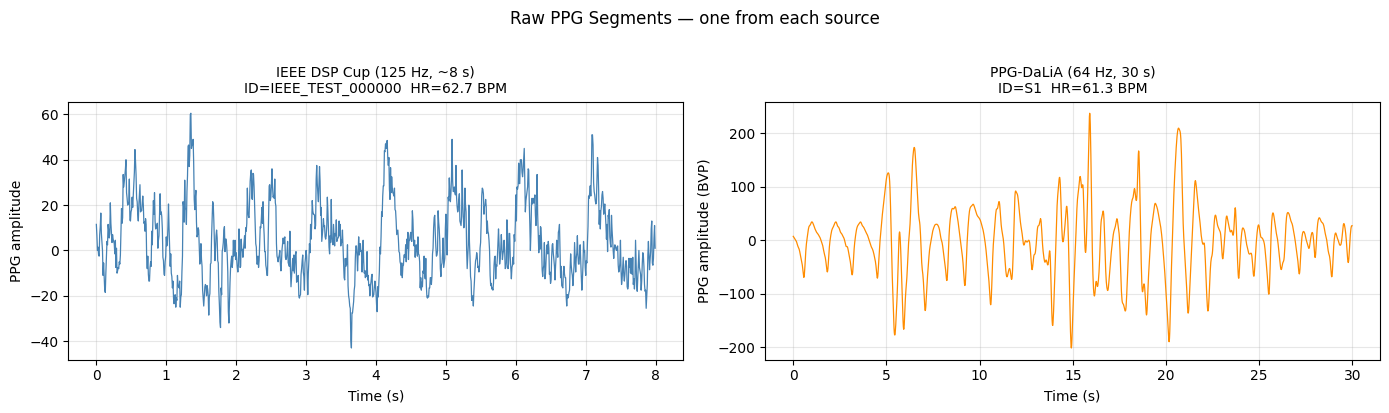

Saved validate_comparison.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

s_ieee  = ieee_samples[0]
s_dalia = dalia_samples[0]

t_ieee  = np.arange(len(s_ieee['signal']))  / s_ieee['sampling_rate']
t_dalia = np.arange(len(s_dalia['signal'])) / s_dalia['sampling_rate']

axes[0].plot(t_ieee,  s_ieee['signal'],  color='steelblue', lw=0.9)
axes[0].set_title(f"IEEE DSP Cup (125 Hz, ~8 s)\n"
                  f"ID={s_ieee['ID']}  HR={s_ieee['label']:.1f} BPM", fontsize=10)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('PPG amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_dalia, s_dalia['signal'], color='darkorange', lw=0.9)
lbl = f"{s_dalia['label']:.1f} BPM" if 'label' in s_dalia else 'N/A'
axes[1].set_title(f"PPG-DaLiA (64 Hz, 30 s)\n"
                  f"ID={s_dalia['ID']}  HR={lbl}", fontsize=10)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('PPG amplitude (BVP)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Raw PPG Segments — one from each source', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('validate_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved validate_comparison.png')